# Decision Tree Example
**Dataset:** Madden 24 Player Ratings

## Objective
This notebook explores the relationship between physical attributes and NFL player positions. Using the Madden 24 Player Ratings dataset, we analyze whether a player's **Height** and **Weight** can accurately predict their on-field position.

We specifically employ a **Decision Tree Classifier** to model these relationships. This approach allows us to visualize how the model creates decision boundaries to distinguish between different physical profiles.

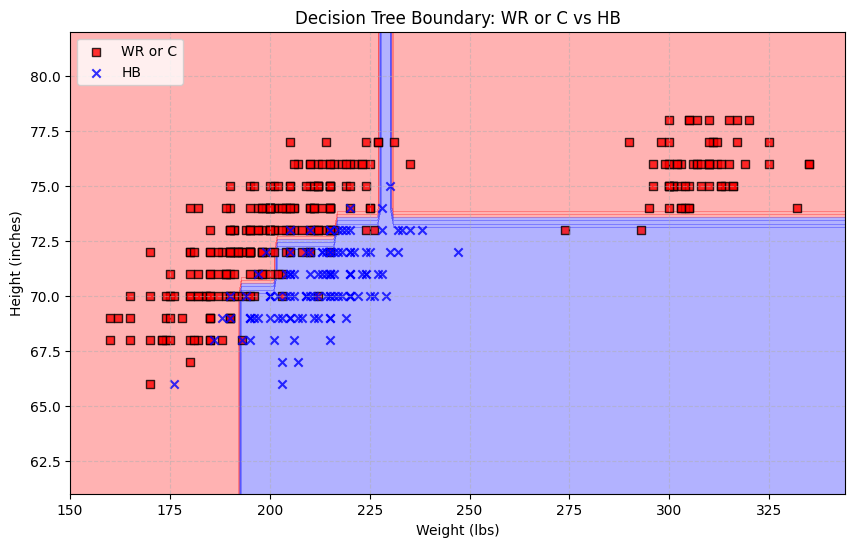

In [9]:

import warnings
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd

from ml import DecisionTree, train_test_split_arrays
import numpy as np


df = pd.read_csv('madden.csv')

# 1. Isolate WR and HB
df_filtered = df[df['Position'].isin(['WR', "C", 'HB'])].copy()

# 2. Map Labels to Integers (WR=0, HB=1) for plotting
# Note: Decision trees handle strings conceptually, but plotting meshes requires numeric mapping
label_map = {'WR': 0, 'C':0, 'HB': 1}
df_filtered['label'] = df_filtered['Position'].map(label_map)

# 3. Select Features (Height, Weight) and Label
X_data = df_filtered[['Weight', 'Height']].values  # X axis: Weight, Y axis: Height
y_data = df_filtered['label'].values

# 4. Split Data
X_train, y_train, X_test, y_test = train_test_split_arrays(X_data, y_data, train_ratio=0.8, seed=42)

# ==========================================
# 3. Training
# ==========================================

clf = DecisionTree(max_depth=4, criterion='entropy')
clf.fit(X_train, y_train)

# ==========================================
# 4. Visualization with Decision Boundaries
# ==========================================
# Suppress the specific UserWarning from matplotlib related to edgecolor for unfilled markers

def plot_decision_boundary(model, X, y, resolution=1.0):
    # Setup marker generator and color map
    markers = ('s', 'x')
    colors = ('red', 'blue')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 10, X[:, 0].max() + 10  # Weight
    x2_min, x2_max = X[:, 1].min() - 5, X[:, 1].max() + 5    # Height
    
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    
    # Predict on the entire meshgrid
    Z = model.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Plot class samples
    for idx, cl in enumerate(np.unique(y)):
        label_name = 'WR or C' if cl == 0 else 'HB'
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=label_name, 
                    edgecolor='black')

    plt.xlabel('Weight (lbs)')
    plt.ylabel('Height (inches)')
    plt.legend(loc='upper left')
    plt.title('Decision Tree Boundary: WR or C vs HB')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()





warnings.filterwarnings('ignore')
# Run visualization
plot_decision_boundary(clf, X_train, y_train)

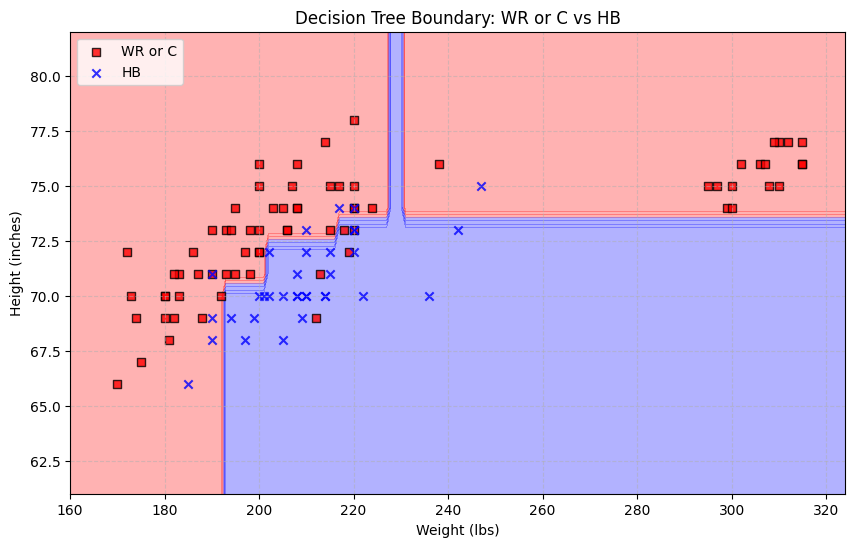

0.8761904761904762

In [10]:
from ml import classification_accuracy

plot_decision_boundary(clf, X_test, y_test)

classification_accuracy(clf, X_test, y_test)



Crucially, this analysis highlights the strength of Decision Trees: they successfully classify the data by creating segmented decision regions, whereas a linear model would fail to separate these clustered positions. It had a good classification accuracy of over 87%.